In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import duckdb
import scipy.stats as stats
import seaborn as sns

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config

In [2]:
import seaborn as sns
import plotly.io as pio
pio.renderers.default = "notebook"  

## Load data

In [3]:
# Load ocen region data
regions_df = pd.read_csv("C:/Users/yvjennig/PycharmProjects/github/ocean_cluster_validation/cluster_set.csv")

# Ensure numeric depth
regions_df["LEV_M"] = pd.to_numeric(regions_df["LEV_M"], errors="coerce")

# Create 3D Point Geometry (longitude, latitude, depth)
regions_df["geometry"] = regions_df.apply(lambda row: Point(row["LONGITUDE"], row["LATITUDE"], row["LEV_M"]), axis=1)

# Convert to a GeoDataFrame
regions_gfdf = gpd.GeoDataFrame(regions_df, geometry="geometry", crs="EPSG:4326")


In [4]:
# Load species and ocean region data
# Connect to DuckDB (in-memory by default)
con = duckdb.connect()

# Query the Parquet files
species_df = con.execute(f"""
    SELECT AphiaID, genus, species, scientificName, decimalLongitude, decimalLatitude, minimumDepthInMeters, maximumDepthInMeters 
    FROM read_parquet('C:/Users/yvjennig/Downloads/OBIS_20250318_parquet/occurrence/*.parquet') 
    WHERE dropped = 'False' AND (genus IS NOT NULL OR species IS NOT NULL) AND minimumDepthInMeters >= 0 AND minimumDepthInMeters IS NOT NULL
    AND decimalLatitude >= {config.grid_config["lat_min"]} AND decimalLatitude <= {config.grid_config["lat_max"]} 
    AND decimalLongitude >= {config.grid_config["lon_min"]} AND decimalLongitude <= {config.grid_config["lon_max"]}  
""").fetchdf()  # Fetch result as a Pandas DataFrame

# Close the connection
con.close()

# Display the first few rows
print(species_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   aphiaid          genus                 species          scientificName  \
0   326622       Aricidea  Aricidea tetrabranchia  Aricidea tetrabranchia   
1   326622       Aricidea  Aricidea tetrabranchia  Aricidea tetrabranchia   
2   240611  Bathyglycinde  Bathyglycinde profunda  Bathyglycinde profunda   
3   130147     Progoniada    Progoniada regularis    Progoniada regularis   
4   130147     Progoniada    Progoniada regularis    Progoniada regularis   

   decimalLongitude  decimalLatitude  minimumDepthInMeters  \
0            -19.15            36.81                4930.0   
1            -21.98            33.03                5230.0   
2            -21.33            34.81                5180.0   
3            -15.63            37.33                4490.0   
4            -21.33            34.81                5180.0   

   maximumDepthInMeters  
0                   NaN  
1                   NaN  
2                   NaN  
3                   NaN  
4                   NaN  


In [5]:
# Drop species without depths
species_df = species_df[(~species_df["minimumDepthInMeters"].isna()) | (~species_df["maximumDepthInMeters"].isna())]

In [6]:
# Ensure numeric depth values
species_df["minimumDepthInMeters"] = pd.to_numeric(species_df["minimumDepthInMeters"], errors="coerce")
species_df["maximumDepthInMeters"] = pd.to_numeric(species_df["maximumDepthInMeters"], errors="coerce")

In [7]:
# Convert species occurrences to a GeoDataFrame
species_geometry = [Point(lon, lat) for lon, lat in zip(species_df["decimalLongitude"], species_df["decimalLatitude"])]
species_gdf = gpd.GeoDataFrame(species_df, geometry=species_geometry, crs="EPSG:4326")

In [8]:
# Map latitude
lat_bins = np.arange(config.grid_config["lat_min"], config.grid_config["lat_max"] + config.grid_config["dlat"], config.grid_config["dlat"]).astype(float)
lat_bins[-1] = lat_bins[-1] + 0.001 * (1 if lat_bins[-1] >= 0 else -1)
species_df["LATITUDE"] = pd.cut(species_df["decimalLatitude"], bins=lat_bins, right=False, labels=lat_bins[:-1] + config.grid_config["dlat"] / 2)

# Map longitude
lon_bins = np.arange(config.grid_config["lon_min"], config.grid_config["lon_max"] + config.grid_config["dlon"], config.grid_config["dlon"]).astype(float)
lon_bins[-1] = lon_bins[-1] + 0.001 * (1 if lon_bins[-1] >= 0 else -1)
species_df["LONGITUDE"] = pd.cut(species_df["decimalLongitude"], bins=lon_bins, right=False, labels=lon_bins[:-1] + config.grid_config["dlon"] / 2)


In [9]:
# Map depth
if config.grid_config["z_array"] is not None:
    z_bins = config.grid_config["z_array"].astype(float) 
else:
    z_bins = np.arange(config.grid_config["z_min"], config.grid_config["z_max"] + config.grid_config["dz"], config.grid_config["dz"]).astype(float)

# z_bins = z_bins + [12000]

if len(z_bins) == 1:
    species_df["LEV_M"] = z_bins[0]
else:
    z_bins[-1] = z_bins[-1] + 0.001  # make sure, last values are included while cutting using pandas
    species_df["LEV_M"] = pd.cut(species_df["minimumDepthInMeters"], bins=z_bins, right=False, labels=z_bins[:-1])

In [10]:
# Remove too deep animals
species_df = species_df[~species_df.LEV_M.isna()]

In [11]:
species_df.head()

,aphiaid,genus,species,scientificName,decimalLongitude,decimalLatitude,minimumDepthInMeters,maximumDepthInMeters,LATITUDE,LONGITUDE,LEV_M
0,326622,Aricidea,Aricidea tetrabranchia,Aricidea tetrabranchia,-19.15,36.81,4930.0,NaN,36.5,-19.5,4000.0
3,130147,Progoniada,Progoniada regularis,Progoniada regularis,-15.63,37.33,4490.0,NaN,37.5,-15.5,4000.0
5,331488,Rhamphobrachium,Rhamphobrachium agassizi,Rhamphobrachium agassizi,-16.00,62.00,2192.0,NaN,62.5,-15.5,2000.0
6,130530,Phylo,Phylo kupfferi,Phylo kupfferi,-10.98,54.90,2433.0,NaN,54.5,-10.5,2000.0
7,130542,Myriochele,Myriochele heeri,Myriochele heeri,1.08,65.47,2730.0,NaN,65.5,1.5,2000.0


## Assign species to ocean regions

In [12]:
# Merge species with regions based on latitude, longitude, and depth bin
species_with_regions = species_df.merge(
    regions_df[["LATITUDE", "LONGITUDE", "LEV_M", "label"]], 
    how="left",
    left_on=["LATITUDE", "LONGITUDE", "LEV_M"],
    right_on=["LATITUDE", "LONGITUDE", "LEV_M"]
)

In [13]:
# Remove cells without labels
species_with_regions = species_with_regions[~species_with_regions.label.isna()]

## Short spatial analysis

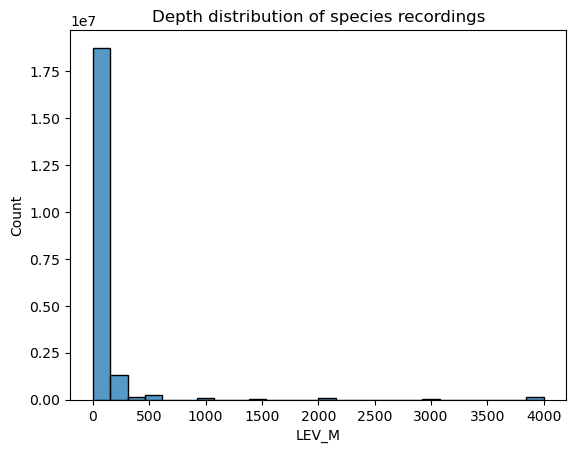

In [14]:
sns.histplot(species_with_regions.LEV_M)
plt.title("Depth distribution of species recordings")
plt.show()
# --> Very few measurements below 500m

In [ ]:
sns.scatterplot(species_with_regions, x="LONGITUDE", y="LATITUDE", hue="LEV_M")
plt.title("Geographic distribution of species recordings")
plt.show()

## Analyse endemicity

In [15]:
level = "aphiaid"

In [16]:
# Filter data for species occurring only in one region
# Count the number of unique 3D regions per species
species_3d_counts = species_with_regions.groupby(level)[["LONGITUDE", "LATITUDE", "LEV_M"]].nunique()

# Identify endemic species (only found in one 3D region)
endemic_3d_species = species_3d_counts[(species_3d_counts == 1).all(axis=1)].index

# Filter data for 3D-endemic species
endemic_3d_species_data = species_with_regions[species_with_regions[level].isin(endemic_3d_species)]

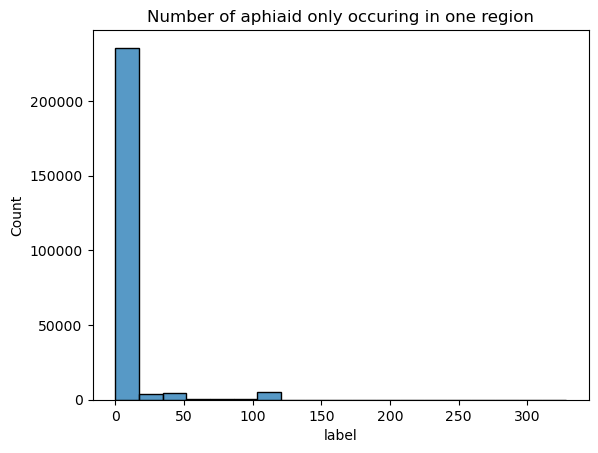

In [17]:
sns.histplot(endemic_3d_species_data.label)
plt.title(f"Number of {level} only occuring in one region")
plt.show()

In [18]:
### Endemicity per ocean region
# Count total species occurrences per ocean region
total_species_per_region = species_with_regions.groupby("label")[level].nunique()

# Count endemic species per ocean region
endemic_species_per_region = endemic_3d_species_data.groupby("label")[level].nunique()

# Compute endemicity percentage per region
endemicity_percentage = (endemic_species_per_region / total_species_per_region) * 100

# Convert to a DataFrame for easy viewing
endemicity_df = endemicity_percentage.reset_index().rename(columns={level: "Endemicity_Percentage"})


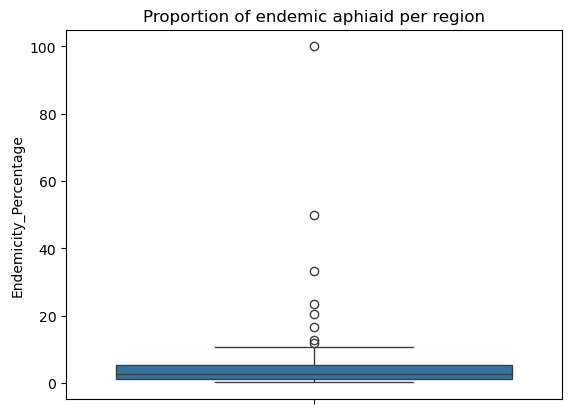

Mean endemicity for the regions: 4.902419703151985


In [19]:
sns.boxplot(endemicity_df.Endemicity_Percentage)
plt.title(f"Proportion of endemic {level} per region")
plt.show()

print(f"Mean endemicity for the regions: {endemicity_df.Endemicity_Percentage.mean()}")

In [20]:
endemicity_df[endemicity_df.Endemicity_Percentage >= 10].sort_values("Endemicity_Percentage", ascending=False)

,label,Endemicity_Percentage
215,263.0,100.000000
217,266.0,50.000000
108,121.0,33.333333
0,0.0,23.386183
122,138.0,20.512821
184,216.0,16.666667
26,27.0,12.616979
6,6.0,11.972217
99,110.0,10.616597


In [ ]:
plot_geo(regions_df[regions_df.label.isin([110, 6])])

In [ ]:
regions_df["LEV_M"] = regions_df["LEV_M"] *-1

In [ ]:
from visualisation.plotting import plot_geo
pio.renderers.default = "browser"

t = endemicity_df[endemicity_df["Endemicity_Percentage"] >= 10].sort_values("Endemicity_Percentage")
plot_geo(regions_df[regions_df.label.isin(list(t.label))])

## Statistical analysis

In [ ]:
# Count endemic species per 3D region
endemic_3d_counts = endemic_3d_species_data.groupby(["LATITUDE", "LONGITUDE", "LEV_M"])[level].nunique()

# Perform a chi-square test to check for significant clustering
chi2_stat, p_value = stats.chisquare(endemic_3d_counts)

print(f"Chi-square Statistic: {chi2_stat}, p-value: {p_value}")

if p_value < 0.05:
    print("Significant association between endemic species and 3D ocean regions.")
else:
    print("No significant association found.")


In [ ]:
# Step 1: Prepare observed and expected counts for the chi-square test
# Observed counts: Endemic species count per region
observed_counts = endemic_species_per_region.values

# Total number of endemic species
total_endemic = observed_counts.sum()

# Step 2: Calculate the expected counts based on the proportion of species in each region
# First, calculate total species count per region
total_species_per_region = species_with_regions.groupby("label")[level].nunique()

# Proportional expected counts for endemic species
expected_counts = total_species_per_region.values * (total_endemic / total_species_per_region.sum())

# Step 3: Chi-square test
chi2_stat, p_value = stats.chisquare(observed_counts, expected_counts)

# Print the results
print(f"Chi-square Statistic: {chi2_stat}, p-value: {p_value}")

# Interpret the result
if p_value < 0.05:
    print("There is a significant difference in the distribution of endemic species across ocean regions.")
else:
    print("No significant difference found in the distribution of endemic species across ocean regions.")


## Visualisation

In [ ]:
import plotly.express as px
import pandas as pd

# Prepare data for plotting
plot_data = species_with_regions.copy()

# Invert depth for visualization (so deeper values are lower in the plot)
plot_data["LEV_M"] = -plot_data["LEV_M"]

# Create interactive 3D scatter plot
fig = px.scatter_3d(
    plot_data, 
    x="LONGITUDE", 
    y="LATITUDE", 
    z="LEV_M",
    color="label",  # Color by ocean region
    hover_data=[level, "label", "LEV_M"],  # Show details on hover
    title="3D Distribution of Endemic Species",
    labels={"LEV_M": "Depth (m)", "decimalLongitude": "Longitude", "decimalLatitude": "Latitude"}
)

# Adjust layout for better 3D viewing
fig.update_layout(
    scene=dict(
        xaxis_title="Longitude",
        yaxis_title="Latitude",
        zaxis_title="Depth (m)",
        zaxis=dict(autorange="reversed"),  # Depth should go downward
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Show the plot
fig.show()